In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [2]:
df = pd.read_parquet("../data/interim/features.parquet")
df.shape

(420767, 47)

In [3]:
X = df.select_dtypes(include=["float64", "int64"])
X = X.dropna()
X.shape

(420010, 41)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 420767 entries, 2009-01-01 00:10:00 to 2016-12-31 23:50:00
Data columns (total 47 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   p (mbar)             420233 non-null  float64
 1   T (degC)             420233 non-null  float64
 2   Tdew (degC)          420233 non-null  float64
 3   rh (%)               420233 non-null  float64
 4   VPact (mbar)         420233 non-null  float64
 5   VPdef (mbar)         420233 non-null  float64
 6   wv (m/s)             420223 non-null  float64
 7   max. wv (m/s)        420223 non-null  float64
 8   wd (deg)             420223 non-null  float64
 9   dT_10                420230 non-null  float64
 10  dT_30                420224 non-null  float64
 11  dT_60                420215 non-null  float64
 12  dp_10                420230 non-null  float64
 13  dp_30                420224 non-null  float64
 14  dp_60                420215 non-nu

In [5]:
iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

iso.fit(X)
iso_scores = -iso.score_samples(X)

(array([1.5000e+01, 1.6900e+02, 6.1900e+02, 1.5540e+03, 3.0560e+03,
        5.1150e+03, 7.6830e+03, 1.0113e+04, 1.2290e+04, 1.3958e+04,
        1.5613e+04, 1.6527e+04, 1.7691e+04, 1.7903e+04, 1.8030e+04,
        1.7743e+04, 1.7294e+04, 1.6610e+04, 1.5868e+04, 1.5367e+04,
        1.4555e+04, 1.3820e+04, 1.3240e+04, 1.2150e+04, 1.1539e+04,
        1.0834e+04, 9.9290e+03, 9.4090e+03, 8.5610e+03, 7.8530e+03,
        7.3300e+03, 6.9260e+03, 6.5790e+03, 5.8350e+03, 5.3560e+03,
        4.9130e+03, 4.4480e+03, 3.8890e+03, 3.6280e+03, 3.3730e+03,
        3.0320e+03, 2.7820e+03, 2.6080e+03, 2.4710e+03, 2.2010e+03,
        2.0030e+03, 1.8170e+03, 1.7300e+03, 1.6290e+03, 1.3490e+03,
        1.3520e+03, 1.0990e+03, 9.6100e+02, 9.1900e+02, 8.4300e+02,
        7.4800e+02, 6.5800e+02, 5.8000e+02, 4.6400e+02, 4.5900e+02,
        3.2800e+02, 3.0800e+02, 2.9200e+02, 2.5100e+02, 2.1300e+02,
        1.9400e+02, 1.8000e+02, 1.6100e+02, 1.2400e+02, 1.1400e+02,
        9.7000e+01, 9.0000e+01, 8.1000e+01, 5.00

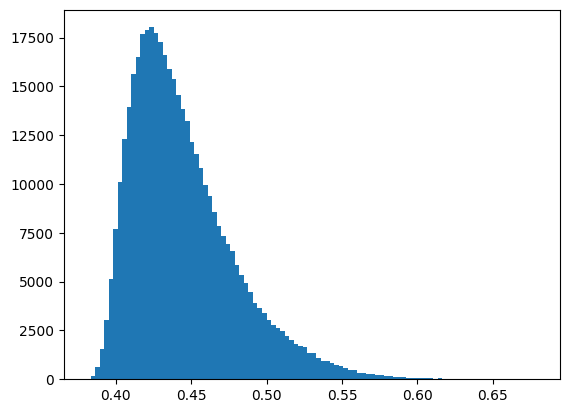

In [6]:
plt.hist(iso_scores, bins=100)

In [7]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    novelty=True,
    contamination="auto"
)
lof.fit(X)

lof_scores = -lof.score_samples(X)

c:\Users\reizi\Documents\Academic\Belajar\DataScience\anomaly-detection-warning-system\anomaly-detection-warning_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


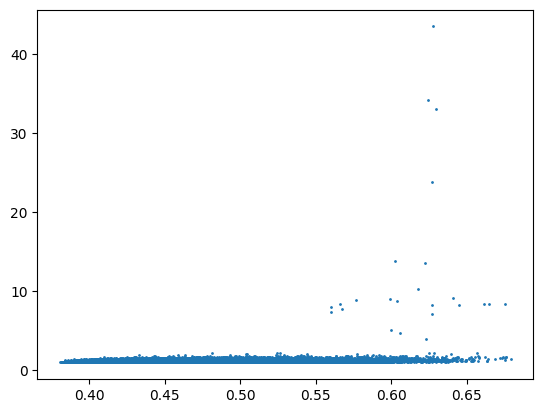

In [8]:
plt.scatter(iso_scores, lof_scores, s=1)    

checking models aggreement: Agreement at extremes, anomaly severity of LOF occured at high or anomolous spot of Isolation Forest
LOF flags very few extreme local anomalies
When it does, IF already thinks they are anomalous

Both models agree on what is extreme - They do not disagree on tails

In [9]:
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)
ocsvm.fit(X)

svm_scores = -ocsvm.score_samples(X)

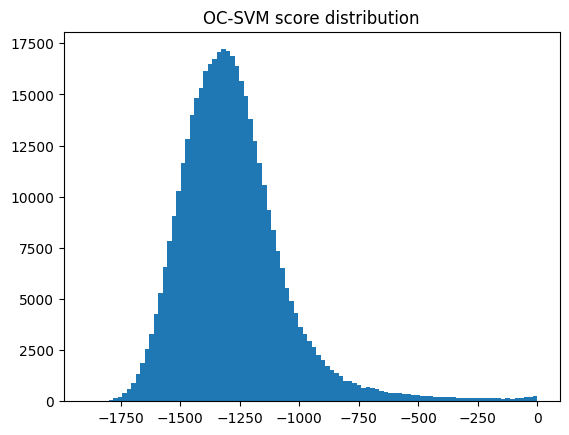

In [12]:
plt.figure()
plt.hist(svm_scores, bins=100)
plt.title("OC-SVM score distribution")
plt.show()

## parameter probing


In [ ]:
# checking sensitivity

ocsvm_alt = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.03   # small change
)
ocsvm_alt.fit(X)

svm_scores_alt = -ocsvm_alt.score_samples(X)

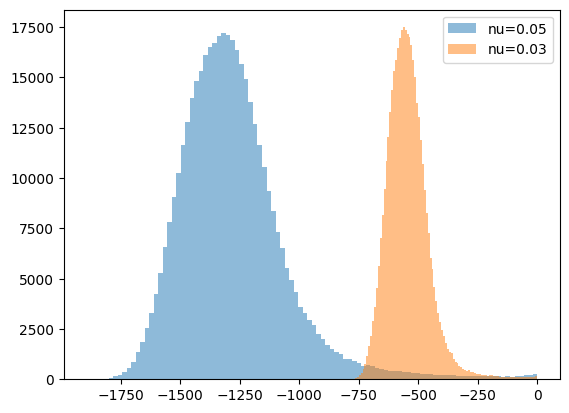

In [17]:
plt.figure()
plt.hist(svm_scores, bins=100, alpha=0.5, label="nu=0.05")
plt.hist(svm_scores_alt, bins=100, alpha=0.5, label="nu=0.03")
plt.legend()
plt.show()


not so much different of shape change = acceptable / stable

In [ ]:
# check stability of isolation forest

scores_list= {}


for n in [100, 200, 300]:
    iso = IsolationForest(
        n_estimators=n,
        contamination="auto",
        random_state=42
    )
    
    iso.fit(X)
    scores_list[n] = -iso.score_samples(X)

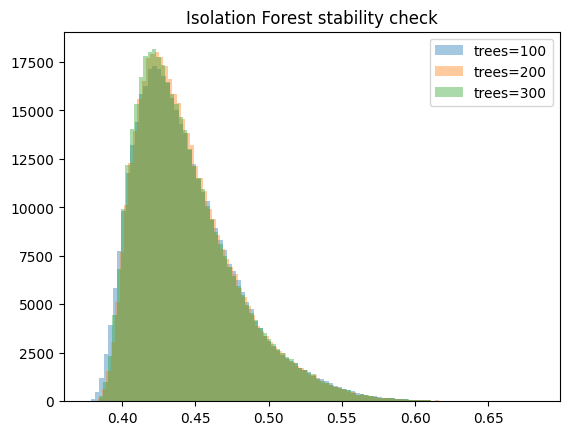

In [33]:
plt.figure()
for n, s in scores_list.items():
    plt.hist(s, bins=100, alpha=0.4, label=f"trees={n}")
plt.legend()
plt.title("Isolation Forest stability check")
plt.show()


simillar shape of his meaning it is stable

In [31]:
lof_scores = {}

for k in [10, 20, 40]:
    lof = LocalOutlierFactor(
        n_neighbors=k,
        novelty=True,
        contamination="auto"
    )
    lof.fit(X)
    lof_scores[k] = -lof.score_samples(X)


c:\Users\reizi\Documents\Academic\Belajar\DataScience\anomaly-detection-warning-system\anomaly-detection-warning_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\reizi\Documents\Academic\Belajar\DataScience\anomaly-detection-warning-system\anomaly-detection-warning_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\reizi\Documents\Academic\Belajar\DataScience\anomaly-detection-warning-system\anomaly-detection-warning_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


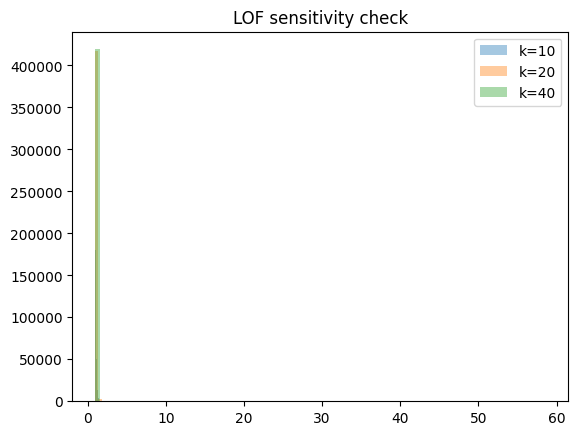

In [34]:
plt.figure()
for k, s in lof_scores.items():
    plt.hist(s, bins=100, alpha=0.4, label=f"k={k}")
plt.legend()
plt.title("LOF sensitivity check")
plt.show()

shape still a one mass

reasonable tail = LOF can be use auxiliary

In [35]:
svm_scores = {}

for nu in [0.03, 0.05, 0.1]:
    svm = OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=nu
    )
    svm.fit(X)
    svm_scores[nu] = -svm.score_samples(X)
 

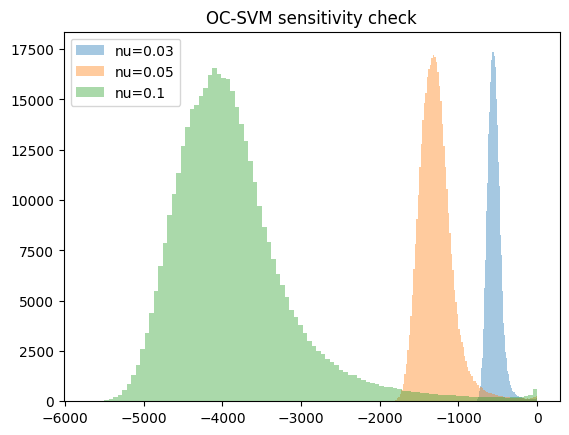

In [ ]:
plt.figure()
for nu, s in svm_scores.items():
    plt.hist(s, bins=100, alpha=0.4, label=f"nu={nu}")
plt.legend()
plt.title("OC-SVM sensitivity check")
plt.show()

model looks unstable by look of difference output if we changing the nu

conclusion
- Which model behaves sensibly = isolation forest (primary model)
- Which model auxiliary = Local Outlier Factor (consistent if we change the n_neighbors and will be good to validate huge event)